# Stage 8 — Noise Robustness

Measure how models degrade under realistic noise conditions. Critical for deployment (vishing calls, telephony, noisy environments).

**Run:** `python scripts/run_noise_robustness.py`

**Output:** `outputs/noise_robustness_results.json`

---

## Experiment Design

| Aspect | Setup |
|--------|-------|
| **Test set** | Speaker-disjoint (same as training pipelines); unseen speakers |
| **Noise types** | **White** (flat spectrum, worst-case), **Pink** (1/f, speech-like), **Compression** (8 kHz bandwidth + quantization, mimics telephony) |
| **SNR levels** | Clean (∞), 20, 10, 5, 0 dB (0 dB = equal signal and noise power) |
| **Models** | **Transformers:** HuBERT, Wav2Vec2, WavLM, Whisper + CNN spectrogram + RF (acoustic) + **Fusion** (frozen HuBERT + acoustic + LR) |
| **Metric** | Test AUC and F1 at each (model, noise_type, SNR) combination |

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from config import NOISE_TYPES, OUTPUTS_DIR, SNR_LEVELS_DB

In [2]:
res_path = OUTPUTS_DIR / "noise_robustness_results.json"
if not res_path.exists():
    raise FileNotFoundError("Run: python scripts/run_noise_robustness.py")

with open(res_path) as f:
    results = json.load(f)

# Build full results table for all subsequent plots
rows = []
for model_name, model_data in results.items():
    for noise_type in NOISE_TYPES:
        if noise_type not in model_data:
            continue
        for snr_label, m in model_data[noise_type].items():
            rows.append({
                "Model": model_name, "Noise": noise_type, "SNR": snr_label,
                "AUC": m["auc"], "F1": m["f1"],
            })
df = pd.DataFrame(rows)
snr_order = ["clean"] + [f"{int(s)}dB" for s in SNR_LEVELS_DB if s != float("inf")]
x_labels = ["Clean"] + [f"{int(s)}" for s in SNR_LEVELS_DB if s != float("inf")]
x_pos = np.arange(len(x_labels))

## Transformers-Only Comparison

All four HF models (HuBERT, Wav2Vec2, WavLM, Whisper) under noise — which architecture is most robust?

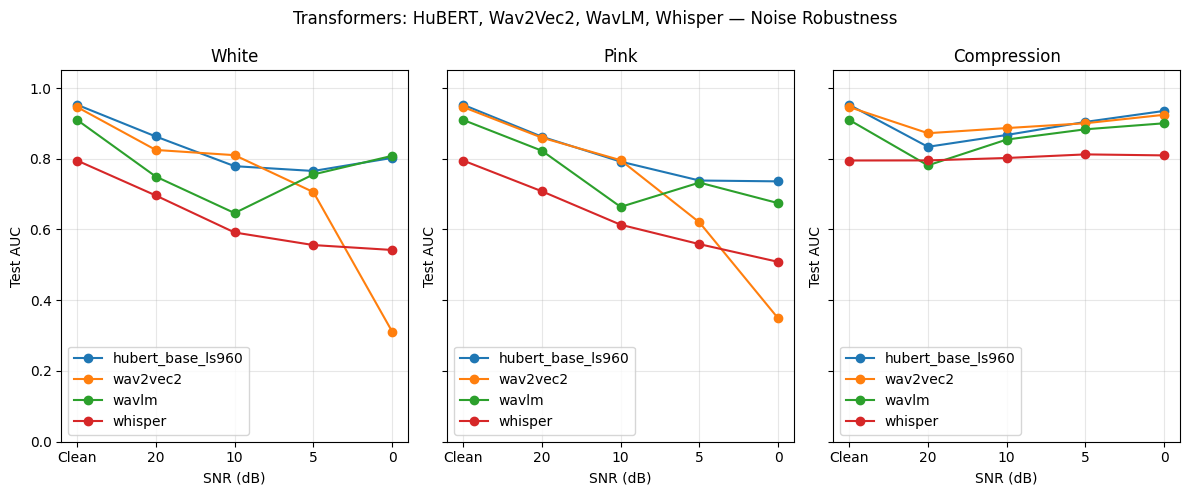

In [3]:
TRANSFORMER_NAMES = ["hubert_base_ls960", "wav2vec2", "wavlm", "whisper"]
transformer_results = {k: v for k, v in results.items() if k in TRANSFORMER_NAMES}
if transformer_results:
    fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(4 * len(NOISE_TYPES), 5), sharey=True)
    if len(NOISE_TYPES) == 1:
        axes = [axes]
    for ax, noise_type in zip(axes, NOISE_TYPES):
        for model_name, model_data in transformer_results.items():
            if noise_type not in model_data:
                continue
            aucs = [model_data[noise_type].get(lbl, {}).get("auc", 0) for lbl in snr_order]
            ax.plot(x_pos, aucs, "o-", label=model_name)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel("Test AUC")
        ax.set_xlabel("SNR (dB)")
        ax.set_title(noise_type.capitalize())
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle("Transformers: HuBERT, Wav2Vec2, WavLM, Whisper — Noise Robustness")
    plt.tight_layout()
    plt.show()

## All Models — Degradation Curves (Test AUC vs SNR)

Transformers + CNN + RF + Fusion. Full comparison.

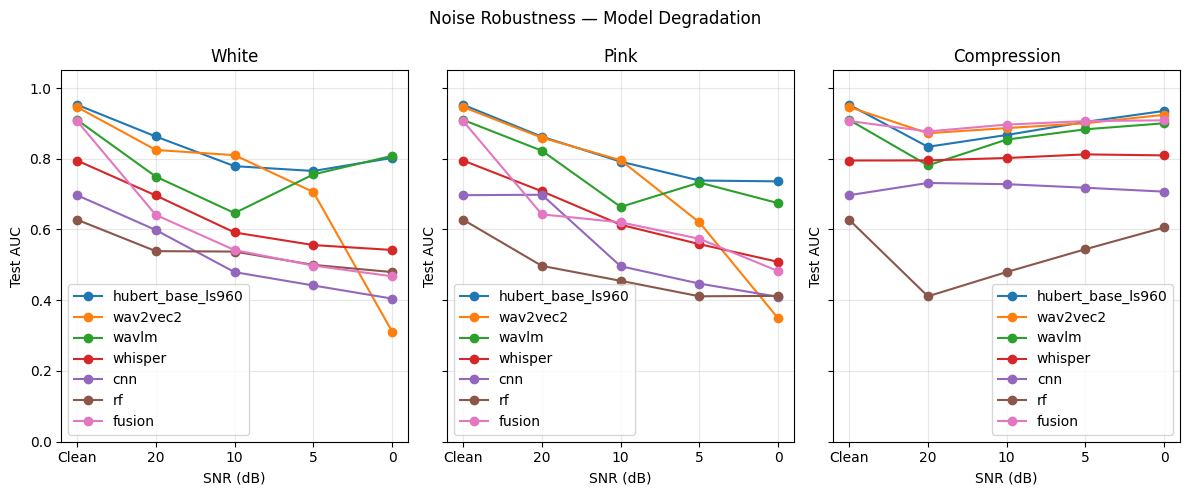

In [4]:
x_pos = np.arange(len(x_labels))

fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(4 * len(NOISE_TYPES), 5), sharey=True)
if len(NOISE_TYPES) == 1:
    axes = [axes]

for ax, noise_type in zip(axes, NOISE_TYPES):
    for model_name, model_data in results.items():
        if noise_type not in model_data:
            continue
        aucs = [model_data[noise_type].get(lbl, {}).get("auc", 0) for lbl in snr_order]
        ax.plot(x_pos, aucs, "o-", label=model_name)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Test AUC")
    ax.set_xlabel("SNR (dB)")
    ax.set_title(noise_type.capitalize())
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Noise Robustness — Model Degradation")
plt.tight_layout()
plt.show()

## Fusion vs HuBERT vs CNN vs RF

Compare Fusion (frozen HuBERT + acoustic features) to:
- **HuBERT (frozen + LR)** — same pipeline as notebook 07 "HuBERT Embeddings Only" (frozen encoder + logistic regression). Use this for a fair comparison with Fusion; clean AUC should align with 07 (~0.88).
- **CNN** (mel-spectrogram)
- **RF** (acoustic features only)

Note: `hubert_base_ls960` in the full results is the **fine-tuned** transformer (encoder + trained head from checkpoint), so its clean AUC (~0.95) is higher than Fusion; that comparison is apples-to-oranges. Here we use `hubert_frozen_lr` to match 07.

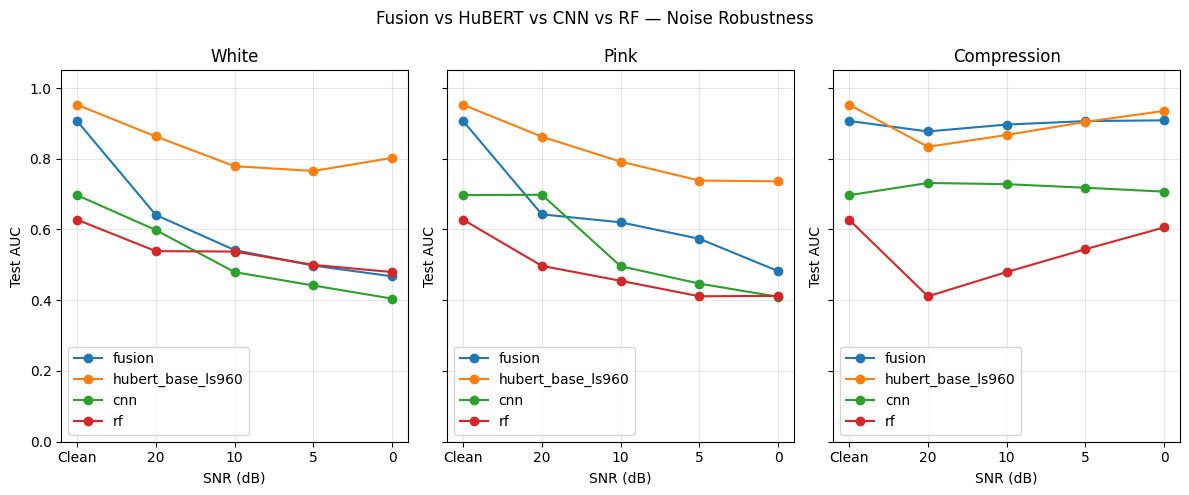

In [5]:
# Fusion vs HuBERT vs CNN vs RF — degradation curves (use hubert_frozen_lr for fair comparison with 07)
FUSION_COMPARE = ["fusion", "hubert_frozen_lr", "cnn", "rf"]
fusion_compare = {k: v for k, v in results.items() if k in FUSION_COMPARE}
if fusion_compare:
    fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(4 * len(NOISE_TYPES), 5), sharey=True)
    if len(NOISE_TYPES) == 1:
        axes = [axes]
    for ax, noise_type in zip(axes, NOISE_TYPES):
        for model_name in FUSION_COMPARE:
            if model_name not in results or noise_type not in results[model_name]:
                continue
            aucs = [results[model_name][noise_type].get(lbl, {}).get("auc", 0) for lbl in snr_order]
            ax.plot(x_pos, aucs, "o-", label=model_name)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel("Test AUC")
        ax.set_xlabel("SNR (dB)")
        ax.set_title(noise_type.capitalize())
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.suptitle("Fusion vs HuBERT vs CNN vs RF — Noise Robustness")
    plt.tight_layout()
    plt.show()

## Grouped Bar Chart — AUC by Model and SNR

Clearer view: each bar = one model at one SNR level. Grouped by SNR for easy comparison. One subplot per noise type.

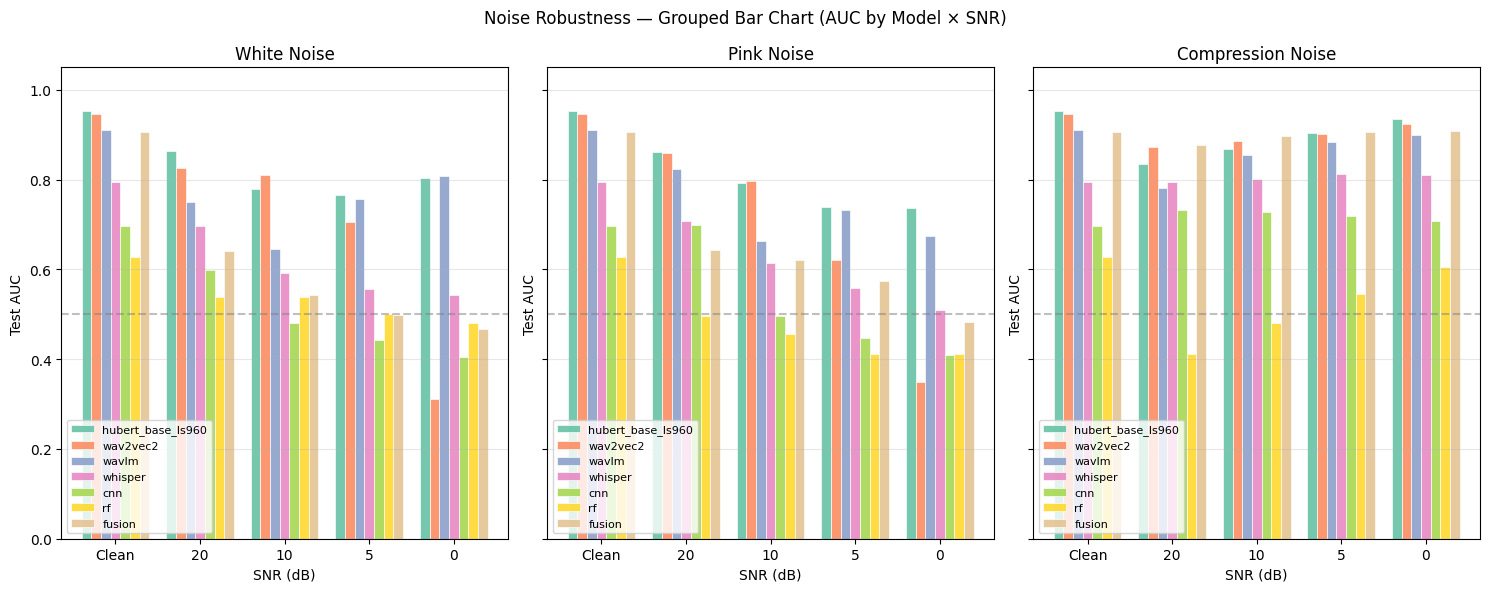

In [6]:
# Grouped bar chart: X = SNR, grouped bars = models
models = list(results.keys())
n_models = len(models)
n_snr = len(snr_order)
x_pos = np.arange(n_snr)
width = 0.8 / n_models

# Color palette (Real=blue, Fake=orange theme; distinct per model)
colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 8)))[:n_models]

fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(5 * len(NOISE_TYPES), 6), sharey=True)
if len(NOISE_TYPES) == 1:
    axes = [axes]

for ax, noise_type in zip(axes, NOISE_TYPES):
    for i, model_name in enumerate(models):
        if noise_type not in results.get(model_name, {}):
            continue
        aucs = [results[model_name][noise_type].get(lbl, {}).get("auc", 0) for lbl in snr_order]
        offset = (i - n_models / 2 + 0.5) * width
        ax.bar(x_pos + offset, aucs, width, label=model_name, color=colors[i], alpha=0.9, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Test AUC")
    ax.set_xlabel("SNR (dB)")
    ax.set_title(noise_type.capitalize() + " Noise")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.legend(loc="lower left", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Noise Robustness — Grouped Bar Chart (AUC by Model × SNR)")
plt.tight_layout()
plt.show()

## Horizontal Bar — Robustness at 0 dB (Worst Case)

Who performs best when noise is strongest? Sorted by AUC at 0 dB.

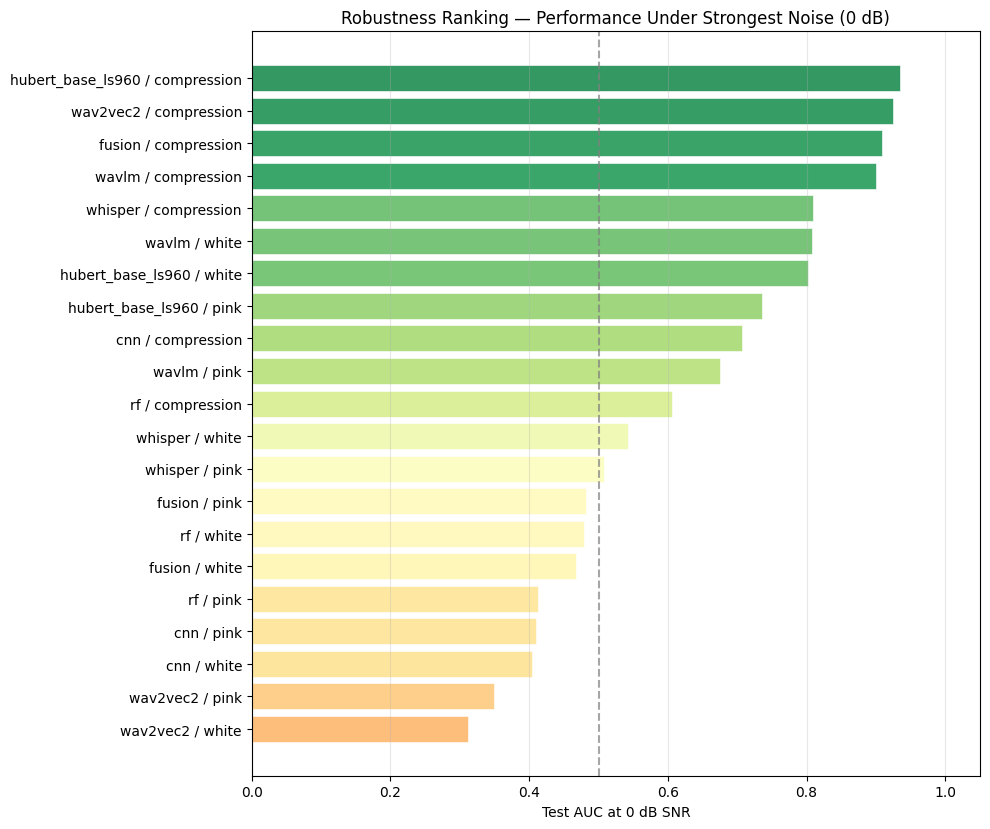

In [7]:
# Horizontal bar: AUC at 0dB for each (model, noise_type) — sorted by robustness
rows_0db = []
for model_name in results:
    for noise_type in NOISE_TYPES:
        if noise_type not in results.get(model_name, {}):
            continue
        auc = results[model_name][noise_type].get("0dB", {}).get("auc", 0)
        rows_0db.append({"Model": model_name, "Noise": noise_type, "AUC_0dB": auc, "Label": f"{model_name} / {noise_type}"})
df_0db = pd.DataFrame(rows_0db).sort_values("AUC_0dB", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_0db) * 0.4)))
colors = plt.cm.RdYlGn(df_0db["AUC_0dB"].values)
bars = ax.barh(df_0db["Label"], df_0db["AUC_0dB"], color=colors, alpha=0.85, edgecolor="white", linewidth=0.5)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.7)
ax.set_xlabel("Test AUC at 0 dB SNR")
ax.set_title("Robustness Ranking — Performance Under Strongest Noise (0 dB)")
ax.set_xlim(0, 1.05)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Summary Table

In [8]:
pivot_auc = df.pivot_table(index=["Model", "Noise"], columns="SNR", values="AUC")
pivot_auc = pivot_auc.reindex(columns=snr_order)
display(pivot_auc.round(3))

SNR                            clean   20dB   10dB    5dB    0dB
Model             Noise                                         
cnn               compression  0.697  0.732  0.728  0.718  0.707
                  pink         0.697  0.698  0.496  0.447  0.410
                  white        0.697  0.598  0.479  0.442  0.405
fusion            compression  0.907  0.877  0.897  0.906  0.909
                  pink         0.907  0.643  0.620  0.574  0.482
                  white        0.907  0.641  0.542  0.498  0.468
hubert_base_ls960 compression  0.953  0.834  0.867  0.904  0.935
                  pink         0.953  0.862  0.792  0.738  0.736
                  white        0.953  0.863  0.779  0.765  0.802
rf                compression  0.628  0.411  0.480  0.544  0.606
                  pink         0.628  0.497  0.455  0.411  0.412
                  white        0.628  0.539  0.538  0.500  0.480
wav2vec2          compression  0.946  0.872  0.887  0.900  0.924
                  pink         0.946  0.860  0.796  0.620  0.349
                  white        0.946  0.825  0.810  0.706  0.311
wavlm             compression  0.910  0.781  0.854  0.883  0.900
                  pink         0.910  0.823  0.664  0.733  0.675
                  white        0.910  0.750  0.646  0.756  0.808
whisper           compression  0.795  0.795  0.802  0.812  0.810
                  pink         0.795  0.708  0.613  0.559  0.508
                  white        0.795  0.696  0.592  0.556  0.542

## F1 Degradation Curves

F1 (balance of precision and recall) under noise — relevant when class balance matters.

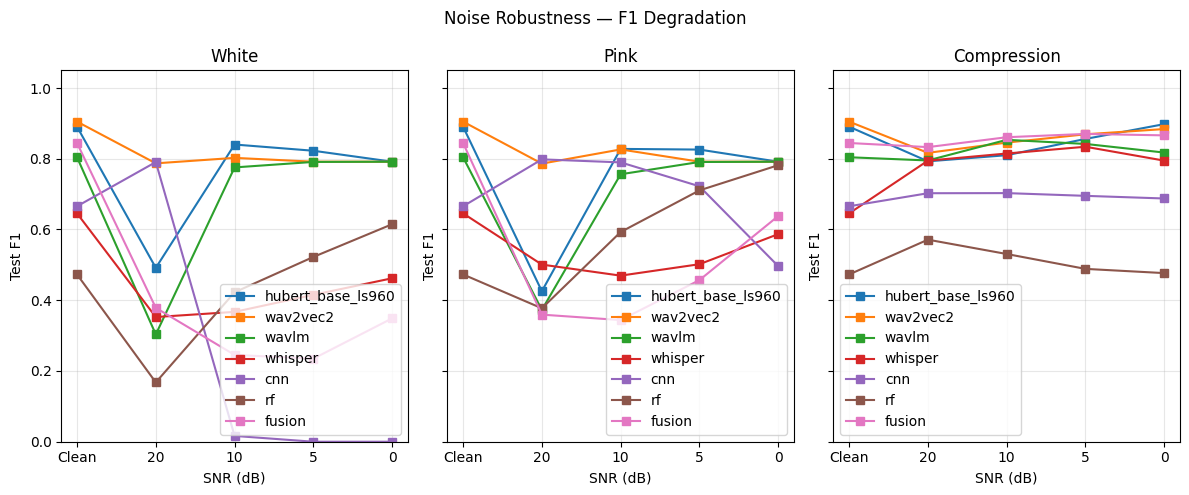

In [9]:
fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(4 * len(NOISE_TYPES), 5), sharey=True)
if len(NOISE_TYPES) == 1:
    axes = [axes]
for ax, noise_type in zip(axes, NOISE_TYPES):
    for model_name, model_data in results.items():
        if noise_type not in model_data:
            continue
        f1s = [model_data[noise_type].get(lbl, {}).get("f1", 0) for lbl in snr_order]
        ax.plot(x_pos, f1s, "s-", label=model_name)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Test F1")
    ax.set_xlabel("SNR (dB)")
    ax.set_title(noise_type.capitalize())
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Noise Robustness — F1 Degradation")
plt.tight_layout()
plt.show()

## Model Comparison at Each SNR

Bar chart: which model performs best at each noise level?

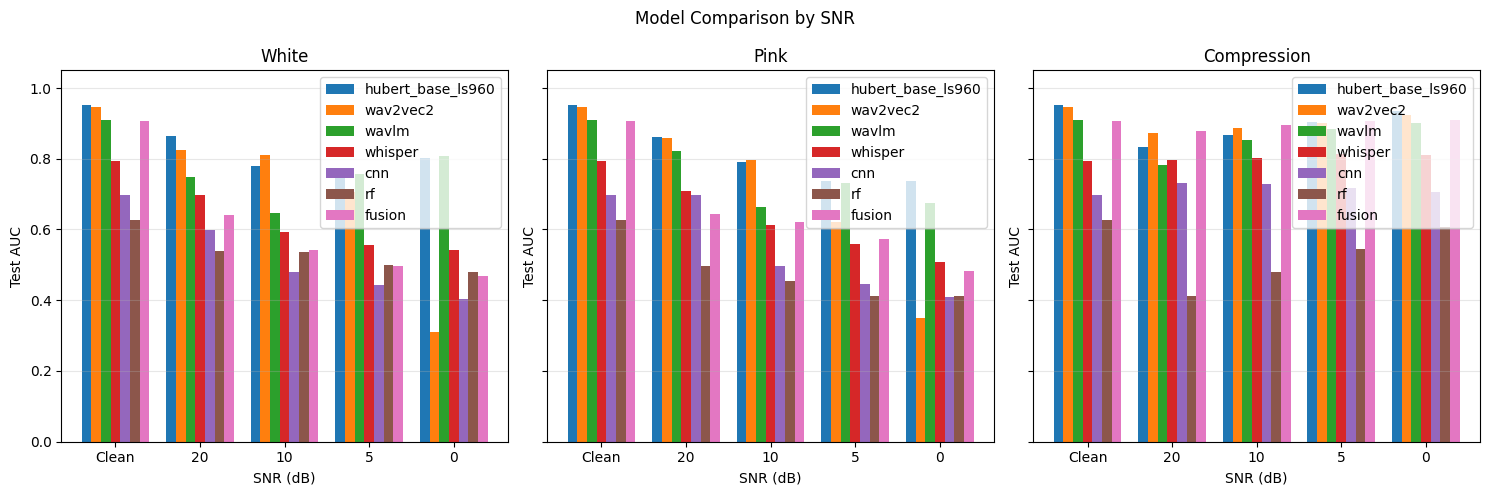

In [10]:
models = list(results.keys())
n_models = len(models)
width = 0.8 / n_models
fig, axes = plt.subplots(1, len(NOISE_TYPES), figsize=(5 * len(NOISE_TYPES), 5), sharey=True)
if len(NOISE_TYPES) == 1:
    axes = [axes]
for ax, noise_type in zip(axes, NOISE_TYPES):
    x = np.arange(len(snr_order))
    for i, model_name in enumerate(models):
        if noise_type not in results.get(model_name, {}):
            continue
        aucs = [results[model_name][noise_type].get(lbl, {}).get("auc", 0) for lbl in snr_order]
        offset = (i - n_models/2 + 0.5) * width
        ax.bar(x + offset, aucs, width, label=model_name)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel("Test AUC")
    ax.set_xlabel("SNR (dB)")
    ax.set_title(noise_type.capitalize())
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")
plt.suptitle("Model Comparison by SNR")
plt.tight_layout()
plt.show()

## Heatmap: AUC by Model × Noise × SNR

Full matrix view — darker = better performance.

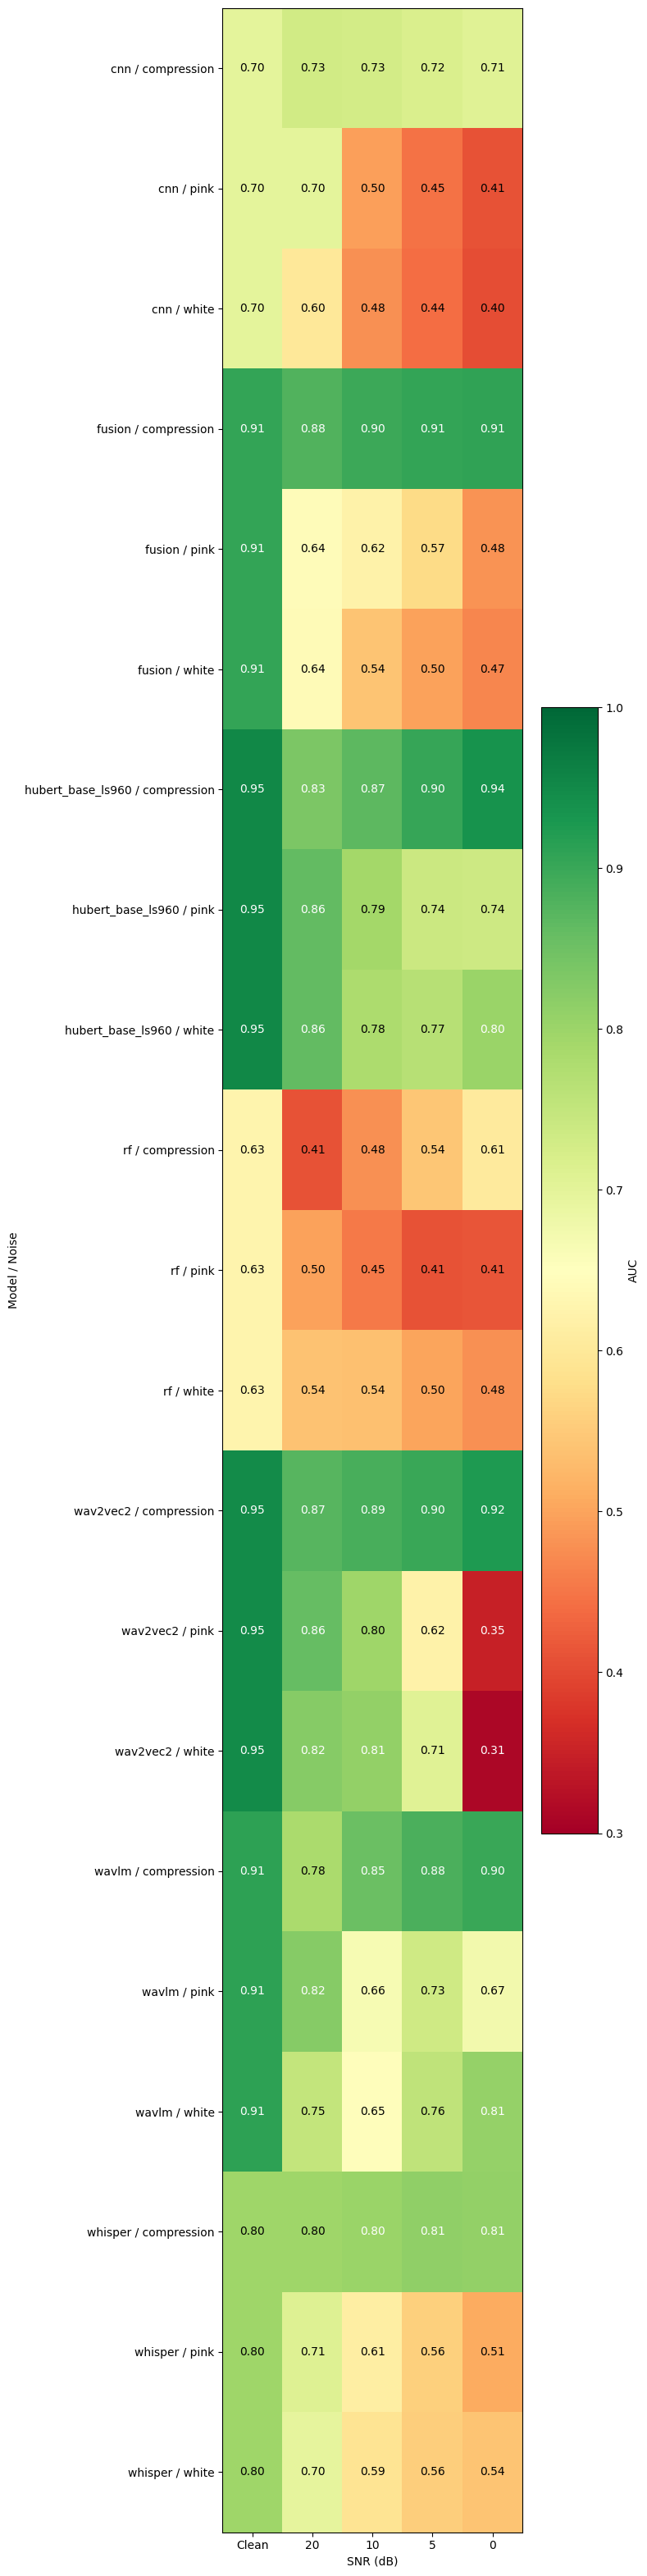

In [11]:
hm = df.pivot_table(index=["Model", "Noise"], columns="SNR", values="AUC")
hm = hm.reindex(columns=snr_order)
fig, ax = plt.subplots(figsize=(8, 1.5 * len(hm)))
im = ax.imshow(hm.values, cmap="RdYlGn", vmin=0.3, vmax=1.0, aspect="auto")
ax.set_xticks(np.arange(len(snr_order)))
ax.set_xticklabels(x_labels)
ax.set_yticks(np.arange(len(hm)))
ax.set_yticklabels([f"{m} / {n}" for m, n in hm.index])
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Model / Noise")
for i in range(len(hm)):
    for j in range(len(snr_order)):
        v = hm.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="black" if 0.4 < v < 0.8 else "white")
plt.colorbar(im, ax=ax, label="AUC")
plt.tight_layout()
plt.show()

## Robustness Ranking

Average AUC drop from clean → 0 dB. Smaller drop = more robust.

In [12]:
ranking = []
for model_name in results:
    for noise_type in NOISE_TYPES:
        if noise_type not in results.get(model_name, {}):
            continue
        d = results[model_name][noise_type]
        clean_auc = d.get("clean", {}).get("auc", 0)
        auc_0db = d.get("0dB", {}).get("auc", 0)
        drop = clean_auc - auc_0db
        ranking.append({"Model": model_name, "Noise": noise_type, "Clean_AUC": clean_auc, "AUC_0dB": auc_0db, "Drop": drop})
rank_df = pd.DataFrame(ranking)
rank_df = rank_df.sort_values("Drop")
display(rank_df.round(3))

,Model,Noise,Clean_AUC,AUC_0dB,Drop
11,whisper,compression,0.795,0.810,-0.014
14,cnn,compression,0.697,0.707,-0.010
20,fusion,compression,0.907,0.909,-0.002
8,wavlm,compression,0.910,0.900,0.010
2,hubert_base_ls960,compression,0.953,0.935,0.017
17,rf,compression,0.628,0.606,0.022
5,wav2vec2,compression,0.946,0.924,0.022
6,wavlm,white,0.910,0.808,0.102
15,rf,white,0.628,0.480,0.148
0,hubert_base_ls960,white,0.953,0.802,0.150


## Conclusions

Data-driven answers to the key questions.

## Data-Driven Conclusions

Answers to the key questions, computed from the results.

In [13]:
# 1. Which model degrades least under noise?
avg_drop = rank_df.groupby("Model")["Drop"].mean().sort_values()
print("Robustness ranking (avg AUC drop clean→0dB, smaller=better):")
print(avg_drop.to_string())
best_robust = avg_drop.idxmin()
print(f"\n→ Most robust: {best_robust}")

# 2. Which noise type is most detrimental?
noise_drop = rank_df.groupby("Noise")["Drop"].mean().sort_values(ascending=False)
print(f"\nNoise severity (avg AUC drop): {noise_drop.to_dict()}")

# 3. Best model at 0 dB SNR?
if "AUC_0dB" in rank_df.columns:
    best_at_0db = rank_df.loc[rank_df["AUC_0dB"].idxmax()]
    print(f"\n→ Best at 0 dB: {best_at_0db['Model']} ({best_at_0db['Noise']}) AUC={best_at_0db['AUC_0dB']:.3f}")

# 4. Transformers comparison
if transformer_results:
    tf_rank = rank_df[rank_df["Model"].isin(TRANSFORMER_NAMES)].groupby("Model")["Drop"].mean().sort_values()
    print(f"\nTransformers robustness: {tf_rank.to_dict()}")

Robustness ranking (avg AUC drop clean→0dB, smaller=better):
Model
wavlm                0.115527
hubert_base_ls960    0.128125
rf                   0.128398
whisper              0.175011
cnn                  0.189938
fusion               0.287213
wav2vec2             0.418187

→ Most robust: wavlm

Noise severity (avg AUC drop): {'pink': 0.3233412619074932, 'white': 0.28848616518435105, 'compression': 0.006343444606501555}

→ Best at 0 dB: hubert_base_ls960 (compression) AUC=0.935

Transformers robustness: {'wavlm': 0.11552671302593454, 'hubert_base_ls960': 0.1281252902006413, 'whisper': 0.1750112438522986, 'wav2vec2': 0.418187090418781}
